<div align="center">

<img src="https://img.shields.io/badge/ECS-Veri%20Bilimi%20%26%20YZ%20Uzmanl%C4%B1%C4%9F%C4%B1-5B2C1E?style=for-the-badge&logo=python&logoColor=white" alt="ECS VB&YZ 90"/>

# Hafta 6: Ek: Titanic Kaggle Cozum

**MAKİNE ÖĞRENMESİ UZMANLIĞI** · Modül 6 · 6 Saat

---

<a href="https://colab.research.google.com/github/DrMuratAltun/VB-YZ-90/blob/main/notebooks/hafta06/ek_titanic_kaggle_cozum.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Colab'da Aç"/></a>&nbsp;
<a href="https://github.com/DrMuratAltun/VB-YZ-90/blob/main/notebooks/hafta06/ek_titanic_kaggle_cozum.ipynb"><img src="https://img.shields.io/badge/GitHub'da%20A%C3%A7-181717?style=flat&logo=github&logoColor=white" alt="GitHub'da Aç"/></a>

</div>

# Titanic - Machine Learning from Disaster


This notebook is for Kaggle - Titanic Machine Learning from Disaster.<br> 
https://www.kaggle.com/competitions/titanic<br>
About Data:
This dataset is about the survival of passengers on the Titanic. 

### Import Libraries and packages

### Veri Setinin Yüklenmesi

Veri setini yükleyip temel bilgilerine bakıyoruz.

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

#machine learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `warnings` | Uyarı yönetimi |


In [5]:
import warnings
warnings.filterwarnings('ignore')

### Loading Data

In [8]:
ls

 Volume in drive C is Windows
 Volume Serial Number is 4821-D018

 Directory of C:\Users\emura\Documents\ABD_YZ_Kursu\Assingments\2-Titanic

18.05.2024  20:21    <DIR>          .
12.05.2024  19:42    <DIR>          ..
25.02.2024  08:47    <DIR>          .ipynb_checkpoints
18.02.2024  11:58             1.512 classification function.txt
19.02.2024  21:04         8.547.303 Hack Day Titanic Project.pptx
19.02.2024  21:03            10.928 info.docx
22.02.2024  19:53            67.952 kaggle_score.jpg
25.02.2024  08:48             4.094 submission.csv
25.02.2024  08:51             3.258 submission2.csv
25.02.2024  08:57             3.258 submission3.csv
25.02.2024  08:58             3.258 submission4.csv
22.02.2024  19:51             6.086 submit.ipynb
21.03.2024  23:44           160.225 Titanic_task2.ipynb
18.05.2024  20:21            58.829 titanic-task.ipynb
19.02.2024  21:03            28.629 ttest.csv
19.02.2024  21:03            61.194 ttrain.csv
              13 File(s)      8.956.52

### Veri Setinin Yüklenmesi

Veri setini yükleyip temel bilgilerine bakıyoruz.

In [9]:
train_data = pd.read_csv("ttrain.csv")
test_data = pd.read_csv("ttest.csv")
combined_data = pd.concat([train_data, test_data], sort=False)

### Exploratory Data Analysis

In [11]:
combined_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### describing the data

In [12]:
#describing the data
combined_data.describe(include=['O']) # that includes categorical

,Name,Sex,Ticket,Cabin,Embarked
count,1309,1309,1309,295,1307
unique,1307,2,929,186,3
top,"Connolly, Miss. Kate",male,CA. 2343,C23 C25 C27,S
freq,2,843,11,6,914


In [13]:
combined_data.describe(include=['number']).T #that includes numerical

,count,mean,std,min,25%,50%,75%,max
PassengerId,1309.0,655.000000,378.020061,1.00,328.0000,655.0000,982.000,1309.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.000,1.0000
Pclass,1309.0,2.294882,0.837836,1.00,2.0000,3.0000,3.000,3.0000
Age,1046.0,29.881138,14.413493,0.17,21.0000,28.0000,39.000,80.0000
SibSp,1309.0,0.498854,1.041658,0.00,0.0000,0.0000,1.000,8.0000
Parch,1309.0,0.385027,0.865560,0.00,0.0000,0.0000,0.000,9.0000
Fare,1308.0,33.295479,51.758668,0.00,7.8958,14.4542,31.275,512.3292


### Check for Missing Values

### Temel İstatistikler

Verinin yapısını, eksik değerleri ve temel istatistikleri inceliyoruz.

In [14]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 132.9+ KB


### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [15]:
combined_data.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

## Data Visualization

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [16]:
# percentage of survived groupby Sex
combined_data["Survived"].value_counts(normalize=True)

Survived
0.0    0.616162
1.0    0.383838
Name: proportion, dtype: float64

### Görselleştirme

Veriyi grafik ile inceliyoruz.

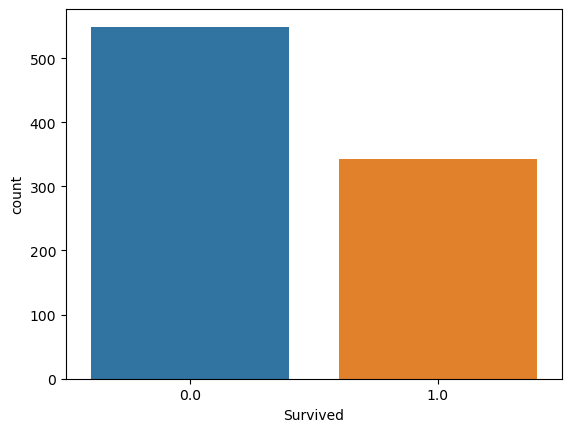

In [17]:
sns.countplot(x="Survived", data=combined_data)
plt.show()

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [ ]:
#combined_data["Survived"].groupby(train_data["Sex"]).value_counts()

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [18]:
train_data["Survived"].groupby(train_data["Sex"]).value_counts(normalize=True)

Sex     Survived
female  1           0.742038
        0           0.257962
male    0           0.811092
        1           0.188908
Name: proportion, dtype: float64

### Görselleştirme

Veriyi grafik ile inceliyoruz.

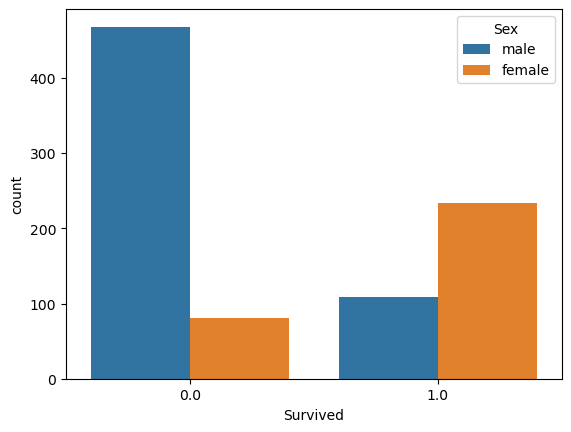

In [19]:
sns.countplot(x="Survived",hue="Sex", data=combined_data)
plt.show()

### Görselleştirme

Veriyi grafik ile inceliyoruz.

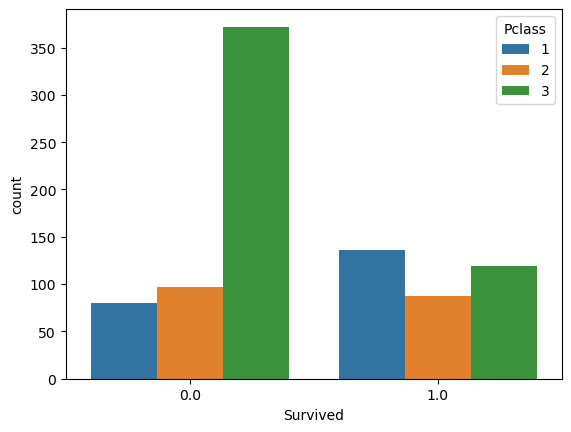

In [20]:
sns.countplot(x="Survived",hue="Pclass", data=combined_data)
plt.show()

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [21]:
total_passengers = combined_data.groupby('Pclass').size().reset_index(name='Total')
survived_passengers = combined_data[combined_data['Survived'] == 1].groupby('Pclass').size().reset_index(name='Survived')
merged_data = pd.merge(total_passengers, survived_passengers, on='Pclass')

In [22]:
merged_data.head()

,Pclass,Total,Survived
0,1,323,136
1,2,277,87
2,3,709,119


In [23]:
merged_data_percentage = merged_data['Survived'] / merged_data['Total'] * 100
merged_data_percentage

0    42.105263
1    31.407942
2    16.784203
dtype: float64

<Axes: xlabel='Pclass', ylabel='Survived'>

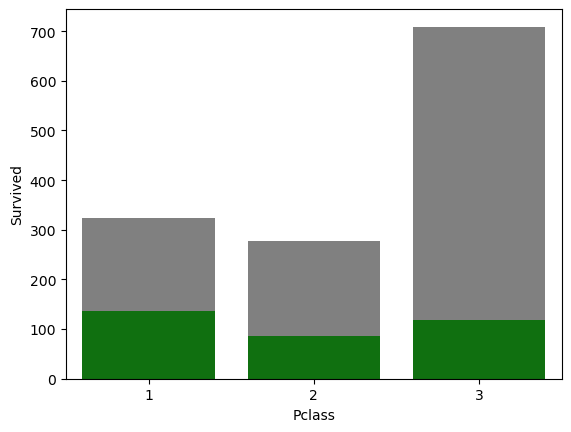

In [24]:
sns.barplot(x="Pclass", y="Total", data=merged_data, color='gray')
sns.barplot(x="Pclass", y="Survived", data=merged_data, color="green", label="Survived")

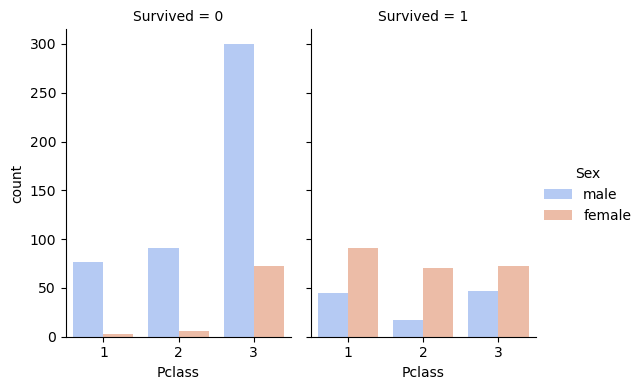

In [25]:
g = sns.catplot(x="Pclass", hue="Sex", col="Survived",
                data=train_data, kind="count",
                height=4, aspect=.7, palette="coolwarm");

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [26]:
combined_data[["Survived", "Pclass"]].groupby(["Pclass"], as_index=False).mean().sort_values(by="Survived", ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [27]:
survival_rates = combined_data.groupby(['Pclass', 'Sex'])['Survived'].agg(['mean', 'count']).reset_index()
survival_rates['Survival Rate'] = survival_rates['mean'] * 100
survival_rates = survival_rates.drop(['mean'], axis=1)
survival_rates.columns = ['Pclass', 'Sex', 'Total Passengers', 'Survival Rate (%)']
survival_rates

,Pclass,Sex,Total Passengers,Survival Rate (%)
0,1,female,94,96.808511
1,1,male,122,36.885246
2,2,female,76,92.105263
3,2,male,108,15.740741
4,3,female,144,50.000000
5,3,male,347,13.544669


### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [28]:
combined_data[["Survived", "Sex"]].groupby(["Sex"], as_index=False).mean().sort_values(by="Survived", ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [29]:
combined_data[["Survived", "Embarked"]].groupby(["Embarked"], as_index=False).mean().sort_values(by="Survived", ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


### Görselleştirme

Veriyi grafik ile inceliyoruz.

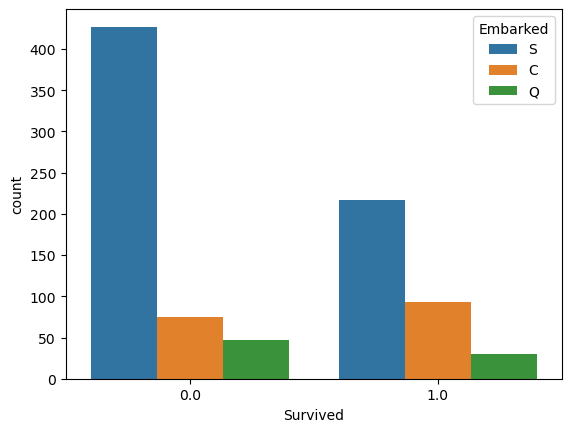

In [30]:
sns.countplot(x="Survived",hue="Embarked", data=combined_data)
plt.show()

### Görselleştirme

Veriyi grafik ile inceliyoruz.

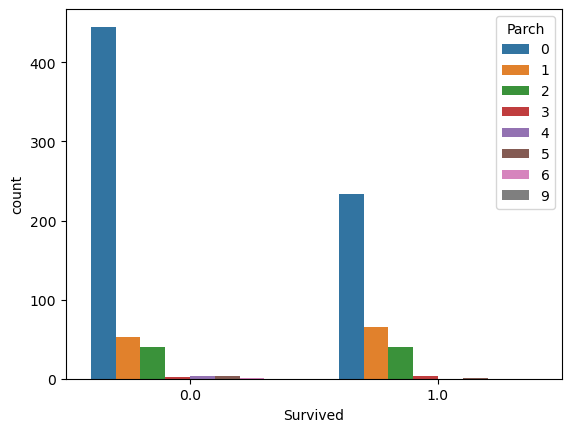

In [31]:
sns.countplot(x="Survived",hue="Parch", data=combined_data)
plt.show()

### Dağılım Analizi

Verinin dağılımını histogram ile inceliyoruz.

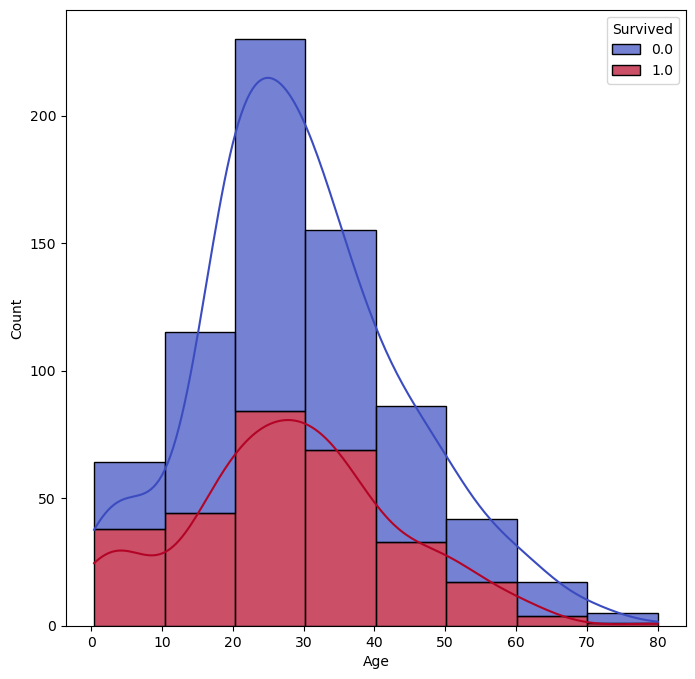

In [32]:
plt.figure(figsize=(8,8))
combined_data = combined_data.reset_index(drop=True)
sns.histplot(data=combined_data, x="Age", hue="Survived", multiple="stack", kde=True, palette="coolwarm", bins=8, alpha=0.7);

### Dağılım Analizi

Verinin dağılımını histogram ile inceliyoruz.

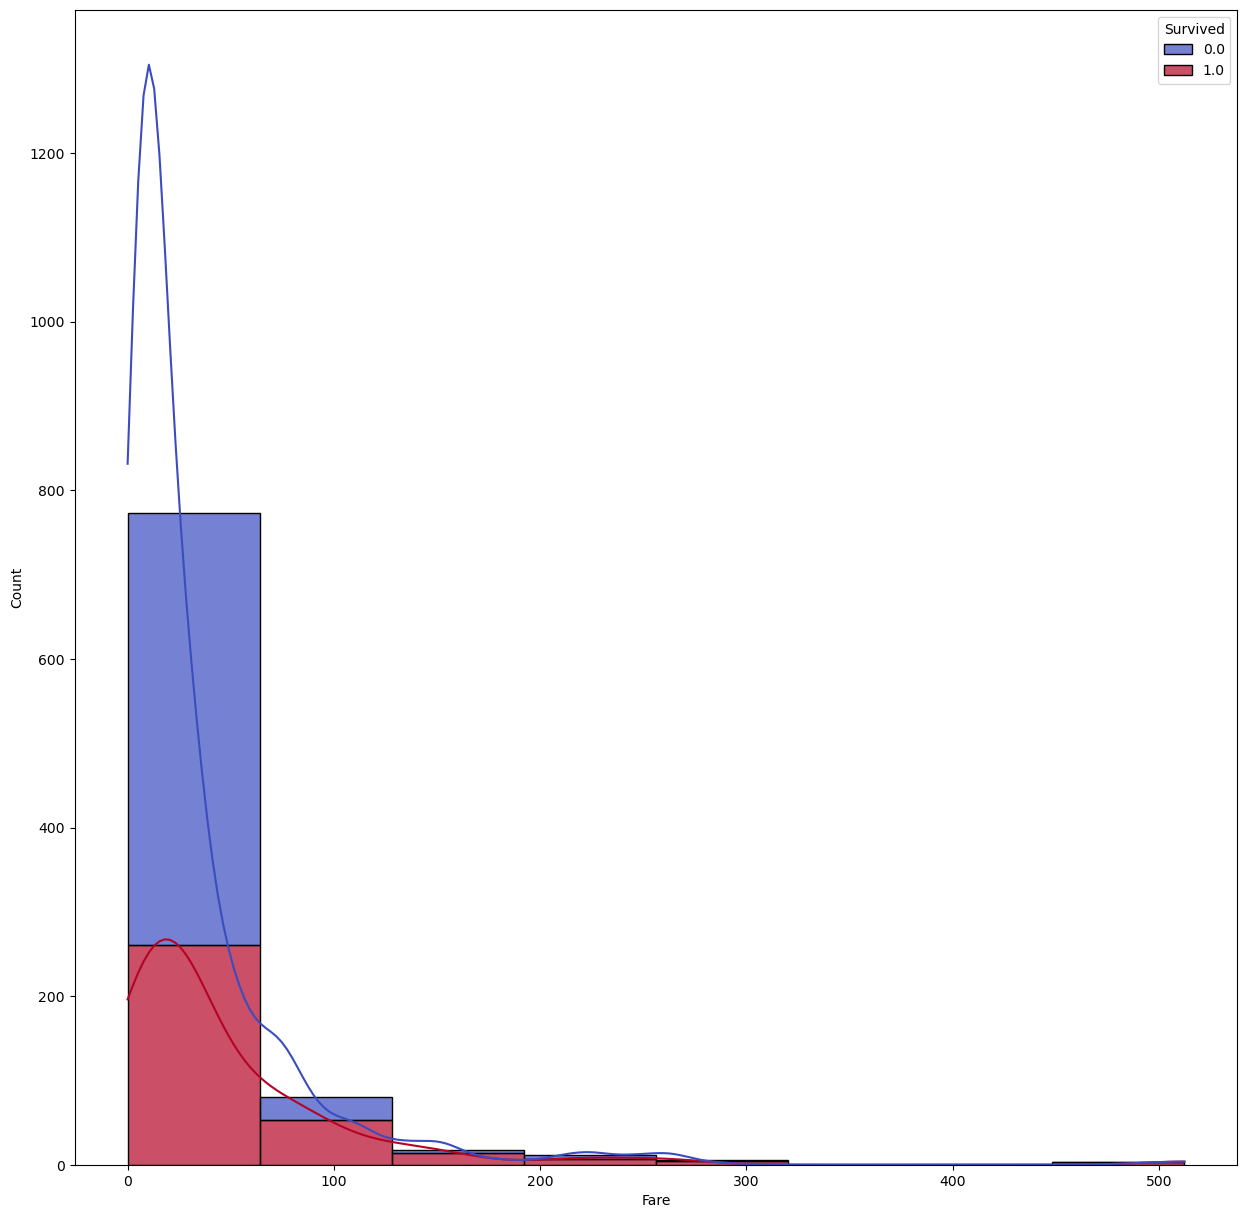

In [33]:
plt.figure(figsize=(15, 15))
combined_data = combined_data.reset_index(drop=True)
sns.histplot(data=combined_data, x="Fare", hue="Survived", multiple="stack", kde=True, palette="coolwarm", bins=8, alpha=0.7);

In [34]:
combined_data["Fare"].max(), combined_data["Fare"].min(),

(512.3292, 0.0)

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [35]:
combined_data["Survived"].groupby(pd.cut(combined_data["Fare"], np.arange(0, 600, 100))).value_counts()

Fare        Survived
(0, 100]    0.0         521
            1.0         302
(100, 200]  1.0          25
            0.0           8
(200, 300]  1.0          11
            0.0           6
(300, 400]  0.0           0
            1.0           0
(400, 500]  0.0           0
            1.0           0
Name: count, dtype: int64

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [36]:
#percentage of survived groupby bin of fare
combined_data["Survived"].groupby(pd.cut(combined_data["Fare"], np.arange(0, 600, 100))).value_counts(normalize=True)

Fare        Survived
(0, 100]    0.0         0.633050
            1.0         0.366950
(100, 200]  1.0         0.757576
            0.0         0.242424
(200, 300]  1.0         0.647059
            0.0         0.352941
(300, 400]  0.0         0.000000
            1.0         0.000000
(400, 500]  0.0         0.000000
            1.0         0.000000
Name: proportion, dtype: float64

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [37]:
#compare survived and not survived state fare >=80 and fare <80
combined_data_fare101 = combined_data[combined_data["Fare"] >= 80]
combined_data_fare100 = combined_data[combined_data["Fare"] < 80]
combined_data_fare101["Survived"].value_counts(normalize=True)


Survived
1.0    0.776316
0.0    0.223684
Name: proportion, dtype: float64

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [38]:
combined_data_fare100 ["Survived"].value_counts(normalize=True)

Survived
0.0    0.652761
1.0    0.347239
Name: proportion, dtype: float64

### Görselleştirme

Veriyi grafik ile inceliyoruz.

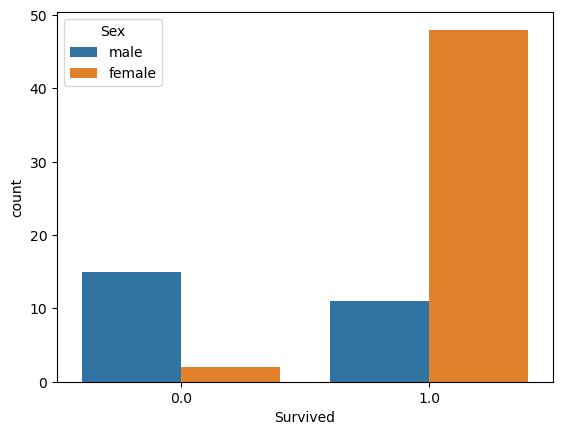

In [39]:
sns.countplot(x="Survived",hue="Sex", data=combined_data_fare101)
plt.show()

### Görselleştirme

Veriyi grafik ile inceliyoruz.

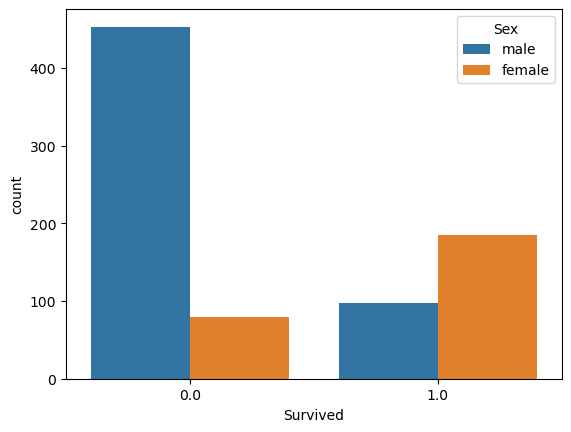

In [40]:
sns.countplot(x="Survived",hue="Sex", data=combined_data_fare100 )
plt.show()

### Görselleştirme

Veriyi grafik ile inceliyoruz.

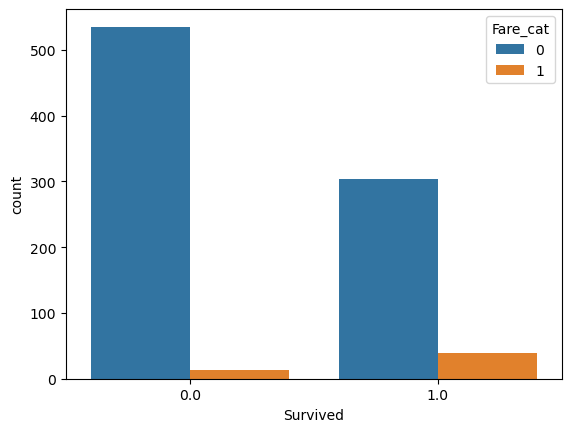

In [41]:

combined_data["Fare_cat"]=combined_data["Fare"].apply(lambda x: 0 if x < 100 else 1)
#visualize
sns.countplot(x="Survived",hue="Fare_cat", data=combined_data)
plt.show()




### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [42]:
#percent survived per sibsp and total survived
combined_data["Survived"].groupby(combined_data["SibSp"]).value_counts(normalize=True)

SibSp  Survived
0      0.0         0.654605
       1.0         0.345395
1      1.0         0.535885
       0.0         0.464115
2      0.0         0.535714
       1.0         0.464286
3      0.0         0.750000
       1.0         0.250000
4      0.0         0.833333
       1.0         0.166667
5      0.0         1.000000
8      0.0         1.000000
Name: proportion, dtype: float64

### Görselleştirme

Veriyi grafik ile inceliyoruz.

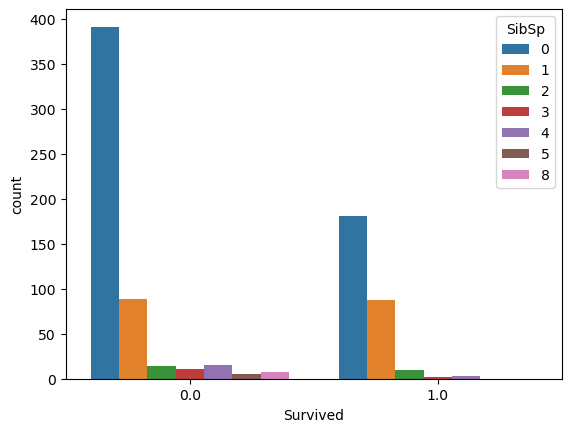

In [43]:
sns.countplot(x="Survived",hue="SibSp", data=combined_data_fare100)
plt.show()

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [44]:
survival_rates = combined_data.groupby(['SibSp', 'Sex'])['Survived'].agg(['mean', 'count']).reset_index()
survival_rates['Survival Rate'] = survival_rates['mean'] * 100
survival_rates = survival_rates.drop(['mean'], axis=1)
survival_rates.columns = ['SibSp', 'Sex', 'Total Passengers', 'Survival Rate (%)']
survival_rates

,SibSp,Sex,Total Passengers,Survival Rate (%)
0,0,female,174,78.735632
1,0,male,434,16.820276
2,1,female,106,75.471698
3,1,male,103,31.067961
4,2,female,13,76.923077
5,2,male,15,20.000000
6,3,female,11,36.363636
7,3,male,5,0.000000
8,4,female,6,33.333333
9,4,male,12,8.333333


### Görselleştirme

Veriyi grafik ile inceliyoruz.

In [45]:
'''combined_data['SibSp_cat'] = train_data["SibSp"].apply(lambda x: 'A' if 0 <= x <= 2 else ('B' if 3 <= x <= 4 else 'C'))
sns.countplot(x="Survived",hue="SibSp_cat", data=train_data)
plt.show()'''

'combined_data[\'SibSp_cat\'] = train_data["SibSp"].apply(lambda x: \'A\' if 0 <= x <= 2 else (\'B\' if 3 <= x <= 4 else \'C\'))\nsns.countplot(x="Survived",hue="SibSp_cat", data=train_data)\nplt.show()'

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [46]:
#combined_data["SibSp_cat"].isnull().sum()

### combined_data[combined_data["SibSp_cat"] == 'C']

In [47]:
#combined_data[combined_data["SibSp_cat"] == 'C']


### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [48]:
'''survival_rates = combined_data.groupby(['SibSp_cat', 'Sex'])['Survived'].agg(['mean', 'count']).reset_index()
survival_rates['Survival Rate'] = survival_rates['mean'] * 100
survival_rates = survival_rates.drop(['mean'], axis=1)
survival_rates.columns = ['SibSp_cat', 'Sex', 'Total Passengers', 'Survival Rate (%)']
survival_rates'''

"survival_rates = combined_data.groupby(['SibSp_cat', 'Sex'])['Survived'].agg(['mean', 'count']).reset_index()\nsurvival_rates['Survival Rate'] = survival_rates['mean'] * 100\nsurvival_rates = survival_rates.drop(['mean'], axis=1)\nsurvival_rates.columns = ['SibSp_cat', 'Sex', 'Total Passengers', 'Survival Rate (%)']\nsurvival_rates"

### Görselleştirme

Veriyi grafik ile inceliyoruz.

In [49]:
''' sns.barplot(x="SibSp_cat", y="Total Passengers", hue="Sex", 
            data=survival_rates, alpha=0.3, palette="coolwarm")

survival_rates['Survived Passengers'] = survival_rates['Total Passengers'] * survival_rates['Survival Rate (%)'] / 100

sns.barplot(x="SibSp_cat", y="Survived Passengers", 
            hue="Sex", data=survival_rates,
            palette="coolwarm")

plt.title('Total and Survived Passengers by SibSp_cat and Sex')
plt.ylabel('Number of Passengers')
plt.show() '''

' sns.barplot(x="SibSp_cat", y="Total Passengers", hue="Sex", \n            data=survival_rates, alpha=0.3, palette="coolwarm")\n\nsurvival_rates[\'Survived Passengers\'] = survival_rates[\'Total Passengers\'] * survival_rates[\'Survival Rate (%)\'] / 100\n\nsns.barplot(x="SibSp_cat", y="Survived Passengers", \n            hue="Sex", data=survival_rates,\n            palette="coolwarm")\n\nplt.title(\'Total and Survived Passengers by SibSp_cat and Sex\')\nplt.ylabel(\'Number of Passengers\')\nplt.show() '

### type(combined_data[['Name']]), type(combined_data['Name'])

In [50]:
#type(combined_data[['Name']]), type(combined_data['Name'])

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|


In [51]:
#extract to title from names
#this expression extracts the title (Mr, Mrs, Miss, etc)
combined_data['Title'] = combined_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
combined_data['Title'].unique()
pd.crosstab(combined_data['Title'], combined_data['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,4
Countess,1,0
Don,0,1
Dona,1,0
Dr,1,7
Jonkheer,0,1
Lady,1,0
Major,0,2


### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [52]:
combined_data['Title'] = combined_data['Title'].replace(['Lady', 'Countess', 'Capt','Col','Don',
                                                 'Dr','Major','Rev', 'Sir','Jonkheer','Dona'],'Rare')
combined_data['Title'] = combined_data['Title'].replace(['Mlle', 'Ms'], 'Miss') 
combined_data['Title'] = combined_data['Title'].replace(['Mme', 'Dona'], 'Mrs')
combined_data[['Title','Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,Master,0.575000
1,Miss,0.702703
2,Mr,0.156673
3,Mrs,0.793651
4,Rare,0.347826


### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [53]:
title_map = {"Mr": 1, "Rare": 2, "Master": 2, "Miss": 4, "Mrs": 4}
combined_data['Title_ord'] = combined_data['Title'].map(title_map)
combined_data['Title_ord']=combined_data['Title_ord'].fillna(0)

In [54]:
combined_data['Sex']=combined_data['Sex'].map({'male':1,'female':0}).astype(int)

In [55]:
combined_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_cat,Title,Title_ord
0,1,0.0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,Mr,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,0,Mrs,4
2,3,1.0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,Miss,4
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,0,Mrs,4
4,5,0.0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,0,Mr,1


### Görselleştirme

Veriyi grafik ile inceliyoruz.

<Axes: xlabel='Survived', ylabel='count'>

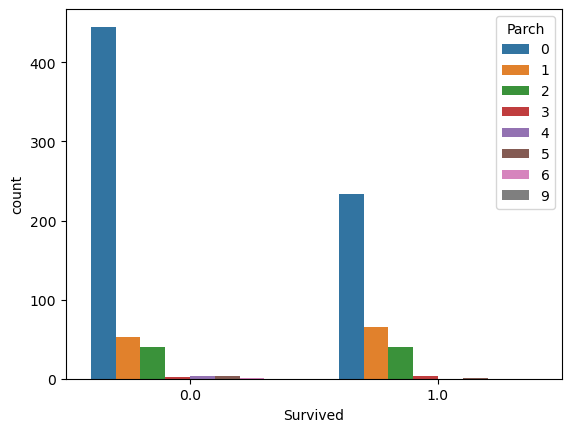

In [56]:
sns.countplot(x="Survived",hue="Parch", data=combined_data)

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [57]:
combined_data[['Parch','Survived']].groupby(['Parch'], as_index=False).mean()

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000
7,9,NaN


### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [58]:
#Parch 1-2-3 --> 3, 4,6,7->1, 0-5 --> 2 mapping
combined_data['Parch_cat']=combined_data['Parch'].map({0:2, 5:2, 4:1, 6:1, 7:1, 1:3, 2:3, 3:3, 9:1})
combined_data.isnull().sum()
#combined_data['Parch_cat'].unique()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
Fare_cat          0
Title             0
Title_ord         0
Parch_cat         0
dtype: int64

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [59]:
combined_data[['Embarked','Survived']].groupby(['Embarked'], as_index=False).mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [60]:
combined_data['Embarked']=combined_data['Embarked'].fillna('Q')
combined_data['Embarked_ord']=combined_data['Embarked'].map({'S':1,'C':2,'Q':1}).astype(int)

In [61]:
combined_data['Sex']

0       1
1       0
2       0
3       0
4       1
       ..
1304    1
1305    0
1306    1
1307    1
1308    1
Name: Sex, Length: 1309, dtype: int32

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [62]:
combined_data['Fare'].fillna(1,inplace=True)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [63]:
combined_data.isnull().sum()

PassengerId        0
Survived         418
Pclass             0
Name               0
Sex                0
Age              263
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin           1014
Embarked           0
Fare_cat           0
Title              0
Title_ord          0
Parch_cat          0
Embarked_ord       0
dtype: int64

In [64]:
combined_data.loc[ combined_data['Age'] <= 16, 'Age'] = 0
combined_data.loc[(combined_data['Age'] > 16) & (combined_data['Age'] <= 32), 'Age'] = 1
combined_data.loc[(combined_data['Age'] > 32) & (combined_data['Age'] <= 48), 'Age'] = 2
combined_data.loc[(combined_data['Age'] > 48) & (combined_data['Age'] <= 64), 'Age'] = 3
combined_data.loc[ combined_data['Age'] > 64, 'Age']
combined_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_cat,Title,Title_ord,Parch_cat,Embarked_ord
0,1,0.0,3,"Braund, Mr. Owen Harris",1,1.0,1,0,A/5 21171,7.2500,NaN,S,0,Mr,1,2,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2.0,1,0,PC 17599,71.2833,C85,C,0,Mrs,4,2,2
2,3,1.0,3,"Heikkinen, Miss. Laina",0,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,Miss,4,2,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,2.0,1,0,113803,53.1000,C123,S,0,Mrs,4,2,1
4,5,0.0,3,"Allen, Mr. William Henry",1,2.0,0,0,373450,8.0500,NaN,S,0,Mr,1,2,1


In [65]:
df=combined_data.drop(['PassengerId','Name',  'Ticket', 'Fare', 'Cabin', 'Embarked','Title'], axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare_cat,Title_ord,Parch_cat,Embarked_ord
0,0.0,3,1,1.0,1,0,0,1,2,1
1,1.0,1,0,2.0,1,0,0,4,2,2
2,1.0,3,0,1.0,0,0,0,4,2,1
3,1.0,1,0,2.0,1,0,0,4,2,1
4,0.0,3,1,2.0,0,0,0,1,2,1


### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [66]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [67]:
df.isnull().sum()

Survived        418
Pclass            0
Sex               0
Age               0
SibSp             0
Parch             0
Fare_cat          0
Title_ord         0
Parch_cat         0
Embarked_ord      0
dtype: int64

In [68]:
train_data = df[:891]
test_data = df[891:]

In [69]:
train_data.shape, test_data.shape

((891, 10), (418, 10))

In [70]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare_cat,Title_ord,Parch_cat,Embarked_ord
0,0.0,3,1,1.0,1,0,0,1,2,1
1,1.0,1,0,2.0,1,0,0,4,2,2
2,1.0,3,0,1.0,0,0,0,4,2,1
3,1.0,1,0,2.0,1,0,0,4,2,1
4,0.0,3,1,2.0,0,0,0,1,2,1


In [71]:
test_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare_cat,Title_ord,Parch_cat,Embarked_ord
891,NaN,3,1,2.0,0,0,0,1,2,1
892,NaN,3,0,2.0,1,0,0,4,2,1
893,NaN,2,1,3.0,0,0,0,1,2,1
894,NaN,3,1,1.0,0,0,0,1,2,1
895,NaN,3,0,1.0,1,1,0,4,3,1


### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [72]:
train_data.isnull().sum()

Survived        0
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare_cat        0
Title_ord       0
Parch_cat       0
Embarked_ord    0
dtype: int64

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `sklearn` | Makine öğrenmesi |


In [73]:
#import Standart scaler
from sklearn.preprocessing import StandardScaler
X_train = StandardScaler().fit_transform(train_data.drop("Survived", axis=1)) #standardize train_data
y_train = train_data["Survived"]
y_test = test_data["Survived"]

X_test = StandardScaler().fit_transform(test_data.drop("Survived", axis=1))

# Modelling

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `sklearn` | Makine öğrenmesi |


In [74]:
from  sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
#accuaracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
def model_classification(X,y):
    '''
    X: independent variable
    y: dependent variable
    return best model and its accuracy
    '''
    x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
    models = [GaussianNB(),BernoulliNB(),LogisticRegression(),RandomForestClassifier(), GradientBoostingClassifier(), KNeighborsClassifier(n_neighbors=5)]
    results=[]
    for model in models:
        model.fit(x_train,y_train)
        model_predict=model.predict(x_test)
        print("Model: ",model)
        print("Model Accuracy: ",accuracy_score(model_predict,y_test))
        print("Model Confusion Matrix: ",confusion_matrix(model_predict,y_test),"\n")
        print("Model Classification Report: ",classification_report(model_predict,y_test))
        print("-"*50)
        results.append(accuracy_score(model_predict,y_test))
    #best model
    best_model=models[results.index(max(results))]
    print("Best Model: ",best_model)
    print("Best Model Accuracy: ",max(results))
    models=pd.DataFrame({
        'Model':['GaussianNB','BernoulliNB','LogisticRegression','RandomForestClassifier', 'GradientBoostingClassifier', 'KNeighborsClassifier'],
        'Score':results})
    print(models.sort_values(by='Score', ascending=False, ignore_index=True))
    return best_model,max(results), confusion_matrix(model_predict,y_test)

In [75]:
model_classification(X_train,y_train)

Model:  GaussianNB()
Model Accuracy:  0.8059701492537313
Model Confusion Matrix:  [[131  26]
 [ 26  85]] 

Model Classification Report:                precision    recall  f1-score   support

         0.0       0.83      0.83      0.83       157
         1.0       0.77      0.77      0.77       111

    accuracy                           0.81       268
   macro avg       0.80      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268

--------------------------------------------------
Model:  BernoulliNB()
Model Accuracy:  0.7835820895522388
Model Confusion Matrix:  [[130  31]
 [ 27  80]] 

Model Classification Report:                precision    recall  f1-score   support

         0.0       0.83      0.81      0.82       161
         1.0       0.72      0.75      0.73       107

    accuracy                           0.78       268
   macro avg       0.77      0.78      0.78       268
weighted avg       0.79      0.78      0.78       268

--------------------

(RandomForestClassifier(),
 0.8208955223880597,
 array([[146,  44],
        [ 11,  67]], dtype=int64))

### Model Eğitimi

Modeli eğitim verisi üzerinde eğitip test verisi üzerinde değerlendiriyoruz.

In [77]:
#whole data
rf_model = RandomForestClassifier()
rf_model.fit(X_train,y_train)

y_pred=rf_model.predict(X_test)
aac = round(rf_model.score(X_train, y_train) * 100, 2) #accuracy_score(X_train, y_train)
print(aac)


87.77


### Veri Setinin Yüklenmesi

Veri setini yükleyip temel bilgilerine bakıyoruz.

In [79]:
test_data = pd.read_csv("ttest.csv")
y_pred=rf_model.predict(X_test)
submission = pd.DataFrame({
        "PassengerId": test_data["PassengerId"],
        "Survived": y_pred.astype(int)
    })
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,0


In [80]:
submission.to_csv('submission.csv', index=False)

### download submission

In [81]:
#download submission
from IPython.display import FileLink
FileLink('submission.csv')

C:\Users\emura\Documents\ABD_YZ_Kursu\Assingments\2-Titanic\submission.csv

---

<div align="center">

<img src="https://img.shields.io/badge/ECS-Veri%20Bilimi%20%26%20YZ-5B2C1E?style=flat-square&logo=python&logoColor=white" alt="ECS"/>

**Dr. Murat Altun** · Veri Bilimi ve Yapay Zeka Eğitmeni

<a href="https://yapayzekaokulum.com">Yapay Zeka Okulum</a> ·
<a href="https://gencyz.com">GençYZ</a> ·
<a href="https://yz-araclari.com">YZ Araçları</a> ·
<a href="https://scholargent.com">ScholarAI</a> ·
<a href="https://drmurataltun.github.io">Kişisel Site</a>

<a href="https://drmurataltun.github.io/VB-YZ-90/">drmurataltun.github.io/VB-YZ-90</a>

---

*Bu materyal ECS Veri Bilimi ve Yapay Zeka Uzmanlığı Programı için hazırlanmıştır.*

© 2026 Dr. Murat Altun. Tüm hakları saklıdır.

</div>